In [4]:
pip install numpy


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd

In [6]:
df = pd.read_excel("Review.xlsx")
df.to_csv("Review.csv", index=False)

In [16]:

num_cols = [
    'work_life_balance',
    'culture_values',
    'career_opp',
    'comp_benefits',
    'senior_mgmt'
]

# Compute global means before chunking
global_means = pd.read_csv("Review.csv", usecols=num_cols, encoding="latin-1").mean()

processed_chunks = []
chunk_size = 10000

for chunk in pd.read_csv("Review.csv", chunksize=chunk_size, encoding="latin-1"):

    chunk = chunk.drop(columns=['diversity_inclusion'])

    # Fill numeric with global mean
    for col in num_cols:
        chunk[col] = chunk[col].fillna(global_means[col])

    # Fill categorical/text
    chunk['location'] = chunk['location'].fillna('No location')
    chunk['headline']  = chunk['headline'].fillna('No headline')
    chunk['pros']      = chunk['pros'].fillna('No pros')
    chunk['cons']      = chunk['cons'].fillna('No cons')

    # Date processing
    chunk['date_review'] = pd.to_datetime(chunk['date_review'])
    chunk['year']  = chunk['date_review'].dt.year
    chunk['month'] = chunk['date_review'].dt.month
    chunk['day']   = chunk['date_review'].dt.day

    # Categorical mapping
    mapping = {'x': 'negative', 'v': 'positive', 'o': 'no opinion', 'r': 'average'}
    chunk['recommend']  = chunk['recommend'].map(mapping)
    chunk['ceo_approv'] = chunk['ceo_approv'].map(mapping)
    chunk['outlook']    = chunk['outlook'].map(mapping)

    # Location splitting — all on chunk 
    chunk[['city', 'region', 'country']] = chunk['location'].str.split(',', n=2, expand=True)
    chunk['city']    = chunk['city'].str.strip()
    chunk['region']  = chunk['region'].str.strip()
    chunk['country'] = chunk['country'].str.strip()

    # Fix mojibake in country
    chunk['country'] = chunk['country'].apply(
        lambda x: x.encode("latin-1").decode("utf-8") if isinstance(x, str) else x
    )

    processed_chunks.append(chunk)

Review = pd.concat(processed_chunks, ignore_index=True)



In [17]:
Review['overall_rating'].mean()
Review.groupby('country')['overall_rating'].mean()#Avg rating by country


country
                    3.500000
AL, Optional[AL]    5.000000
Abra                4.000000
Abruzzo             4.000000
Acre                4.000000
                      ...   
Zhejiang            4.187500
Zug                 3.769231
ZÃ¼rich             3.222222
ÃÃ  Náºµng         3.888889
ÃŽle-de-France      4.250000
Name: overall_rating, Length: 505, dtype: float64

In [18]:
len(Review['city'])
print(Review[['city', 'region', 'country']])


               city            region           country
0       No location              None              None
1        Bromsgrove           England           England
2        Bromsgrove           England           England
3       No location              None              None
4        Bromsgrove           England           England
...             ...               ...               ...
838561   MÃÂ¼nchen           Bavaria           Bavaria
838562       London           England           England
838563  No location              None              None
838564  No location              None              None
838565       Kladno  Central Bohemian  Central Bohemian

[838566 rows x 3 columns]


In [19]:
'recommend', 'ceo_approv','outlook' in Review.columns
recommend_counts = Review['recommend'].value_counts()
print(recommend_counts)

recommend
positive      427865
no opinion    234248
negative      176453
Name: count, dtype: int64


In [20]:
Review['region'] = Review['region'].fillna('Unknown')
Review['country'] = Review['country'].fillna('Unknown')

In [21]:
Review.isnull().sum()

firm                 0
date_review          0
job_title            0
current              0
location             0
overall_rating       0
work_life_balance    0
culture_values       0
career_opp           0
comp_benefits        0
senior_mgmt          0
recommend            0
ceo_approv           0
outlook              0
headline             0
pros                 0
cons                 0
year                 0
month                0
day                  0
city                 0
region               0
country              0
dtype: int64

In [22]:
cols = [
    'work_life_balance',
    'culture_values',
    'career_opp',
    'comp_benefits'
]

Review[cols] = Review[cols].astype(int)

In [23]:
ceo_approv_counts = Review['ceo_approv'].value_counts()
print(ceo_approv_counts)
outlook_counts = Review['outlook'].value_counts()
print(outlook_counts)

ceo_approv
no opinion    311433
positive      286695
average       176930
negative       63508
Name: count, dtype: int64
outlook
positive      301413
no opinion    294548
average       154948
negative       87657
Name: count, dtype: int64


In [24]:
print(Review['firm'])

0         AFH-Wealth-Management
1         AFH-Wealth-Management
2         AFH-Wealth-Management
3         AFH-Wealth-Management
4         AFH-Wealth-Management
                  ...          
838561           the-LEGO-Group
838562           the-LEGO-Group
838563           the-LEGO-Group
838564           the-LEGO-Group
838565           the-LEGO-Group
Name: firm, Length: 838566, dtype: object


In [25]:
# Review['location'].nunique()
Review['location'].value_counts().head(10)

location
No location                  297343
London, England, England      58665
New York, NY                  31172
Bangalore                     28102
HyderÃÂbÃÂd               11458
Mumbai                         9543
Gurgaon, Haryana, Haryana      8562
Chicago, IL                    7840
Singapore                      7581
San Francisco, CA              7371
Name: count, dtype: int64

In [26]:
print(Review[['city', 'region', 'country']])

               city            region           country
0       No location           Unknown           Unknown
1        Bromsgrove           England           England
2        Bromsgrove           England           England
3       No location           Unknown           Unknown
4        Bromsgrove           England           England
...             ...               ...               ...
838561   MÃÂ¼nchen           Bavaria           Bavaria
838562       London           England           England
838563  No location           Unknown           Unknown
838564  No location           Unknown           Unknown
838565       Kladno  Central Bohemian  Central Bohemian

[838566 rows x 3 columns]


In [27]:
# Location splitting
chunk[['city', 'region', 'country']] = chunk['location'].str.split(',', n=2, expand=True)
chunk['city']    = chunk['city'].str.strip()
chunk['region']  = chunk['region'].str.strip()
chunk['country'] = chunk['country'].str.strip()

# Fix  (ZÃ¼rich → Zürich, ÃŽle-de-France → Île-de-France)
chunk['country'] = chunk['country'].apply(
    lambda x: x.encode("latin-1").decode("utf-8") if isinstance(x, str) else x
)

# Optional but recommended: normalize unicode + fix casing
import unicodedata
chunk['country'] = chunk['country'].apply(
    lambda x: unicodedata.normalize("NFC", x).strip().title() if isinstance(x, str) else x
)

In [28]:
# print(Review['country'])

In [29]:
Review = pd.concat(processed_chunks, ignore_index=True)

print("Total rows:", len(Review))
print("Unique countries:", Review['country'].nunique())
print("\nCountry list:")
print(sorted(Review['country'].dropna().unique()))


Total rows: 838566
Unique countries: 508

Country list:
['', 'AL, Optional[AL]', 'Abra', 'Abruzzo', 'Acre', 'Adamaoua', 'Adana', 'Aguascalientes', 'Aichi', 'Aklan', 'Alagoas', 'Alajuela', 'AmapÃ¡', 'Amazonas', 'Amman Governorate', 'Andalusia', 'Andhra Pradesh', 'Angleterre', 'Anhui', 'Ankara', 'Antioquia', 'Antique', 'AnzoÃ¡tegui', 'Aquitaine', 'Aragua', 'Arequipa', 'Argovia', 'Arunachal Pradesh', 'Ashanti', 'Assam', 'Asturias', 'AtlÃ¡ntico', 'Attica', 'Attica, Attica', 'Auckland', 'Babil Governorate', 'Bacolod', 'Baden-Wurttemberg', 'Baden-WÃ¼rttemberg', 'Baguio', 'Bahia', 'Baja California', 'Bali', 'Balochistan', 'Bandundu', 'Banten', 'Bas-Congo', 'Bashkortostan', 'Basque Country', 'Bataan', 'Bavaria', 'Bayern', 'Baá¸©r al Jabal', 'Beijing', 'Belize', 'Benue', 'Bern', 'Bihar', 'Bistrita-Nasaud', 'Bogota', 'BolÃ\xadvar', 'Borno', 'Bosnia Serb Republic', 'Braga', 'Bremen', 'Bucuresti', 'Budapest', 'Bulacan', 'Bulawayo', 'Butuan', 'CA, Optional[CA]', 'CO, Optional[CO]', 'Caloocan', 'Cam

In [30]:
pip install ftfy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [31]:
import ftfy

# Step 1 — Fix mojibake properly (ftfy handles all cases)
Review['country'] = Review['country'].apply(
    lambda x: ftfy.fix_text(x) if isinstance(x, str) else x
)

# Step 2 — Remove Optional[AL] pattern
Review['country'] = Review['country'].str.replace(r'Optional\[.*?\]', '', regex=True)

# Step 3 — Remove commas, extra spaces
Review['country'] = Review['country'].str.replace(',', '', regex=False)
Review['country'] = Review['country'].str.strip()

# Step 4 — Replace empty strings with NA
Review['country'] = Review['country'].replace('', pd.NA)

# Step 5 — Title case
Review['country'] = Review['country'].str.title()

# Step 6 — Map regions/states to correct countries
Review['country'] = Review['country'].replace({
    'Abra': 'Philippines',
    'Acre': 'Brazil',
    'Abruzzo': 'Italy',
    'Adamaoua': 'Cameroon',
    'West Java': 'Indonesia',
    'Nordland': 'Norway',
    'Saarema': 'Estonia',
    'Misamis Occidental': 'Philippines',
    'Baden-Württemberg': 'Germany',
})

In [32]:
print(Review['country'].unique())

[None 'England' 'England England' 'Wales'
 'South West England England England' 'Scotland'
 'East Midlands England England' 'Wales Wales'
 'North West England England England' 'South East England England England'
 'West Midlands England England' 'Northern Ireland'
 'Yorkshire And The Humber England England'
 'Northern Ireland Northern Ireland' 'Scotland Scotland' 'Lima Region'
 'East Of England England England' 'Antioquia' 'Pernambuco' 'Tehran'
 'Madhya Pradesh' 'Western Australia' 'Aichi' 'Bayern' 'Ca' 'São Paulo'
 'México' 'Haryana' 'Sarawak' 'Shanghai' 'Fujairah' 'Bavaria'
 'Mato Grosso Do Sul' 'Greater Poland' 'Lublin' 'Yogyakarta' 'Braga'
 "Tyumenskaya Oblast'" 'Federal District' "Voronezhskaya Oblast'" 'Yunnan'
 'Aquitaine' 'Hainan' 'Lagos' 'Pa' <NA> 'Södermanland' 'Rajasthan'
 'Oporto' 'Ga' 'Bogota' 'Maharashtra' 'Lower Saxony' 'Emilia-Romagna'
 'East Flanders' 'Karnataka' 'Chhattisgarh' 'Västmanland' 'Tuscany'
 'Queensland' 'Southern Finland' 'Budapest' 'Zhejiang' 'Valle Del Ca

In [37]:
print(Review['job_title'])

0                                        
1                    Office Administrator
2                    Office Administrator
3                                        
4                    Office Administrator
                       ...               
838561                  Marketing Manager
838562                    Sales Associate
838563                         Strategist
838564    Customer Service Representative
838565         Human Resources Specialist
Name: job_title, Length: 838566, dtype: object


In [38]:
import re

def clean_job_title(text):
    if not isinstance(text, str):
        return text

    # Fix mojibake if present
    try:
        text = text.encode("latin-1").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        pass

    # Remove special characters, keep letters, numbers, spaces, hyphens
    text = re.sub(r'[^a-zA-Z0-9\s\-\/\&\(\)]', '', text)

    # Fix extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Title case
    text = text.title()

    return text

Review['job_title'] = Review['job_title'].apply(clean_job_title)

# Verify
print(Review['job_title'].value_counts().head())

job_title
Anonymous Employee    162649
                       79068
Manager                15210
Consultant             12646
Software Engineer      10902
Name: count, dtype: int64


In [39]:
print(Review['job_title'])

0                                        
1                    Office Administrator
2                    Office Administrator
3                                        
4                    Office Administrator
                       ...               
838561                  Marketing Manager
838562                    Sales Associate
838563                         Strategist
838564    Customer Service Representative
838565         Human Resources Specialist
Name: job_title, Length: 838566, dtype: object


In [40]:
def rating_bucket(val):
    if val >= 1 and val < 2:
        return "1 to 2"
    elif val >= 2 and val < 3:
        return "2 to 3"
    elif val >= 3 and val < 4:
        return "3 to 4"
    elif val >= 4 and val <= 5:
        return "4 to 5"
    else:
        return None

Review['Rating_Bucket_WLB'] = Review['work_life_balance'].apply(rating_bucket)

In [41]:
# print(Review['Rating_Bucket_WLB'])

In [42]:
# print(Review.columns)

In [43]:
# Review.info()

In [44]:
# print(Review['current'])

In [45]:
Review[['employee_status', 'timeduration']] = Review['current'].str.split(',', n=1, expand=True)

# Clean extra spaces
Review['employee_status'] = Review['employee_status'].str.strip()
Review['timeduration'] = Review['timeduration'].str.strip()

print(Review['employee_status'])

0         Current Employee
1         Current Employee
2         Current Employee
3         Current Employee
4         Current Employee
                ...       
838561    Current Employee
838562    Current Employee
838563    Current Employee
838564    Current Employee
838565    Current Employee
Name: employee_status, Length: 838566, dtype: object


In [46]:
# print(Review['timeduration'])

In [47]:
# Review = Review.drop(columns=['current'])

In [48]:
# Review=Review.drop(columns=['timeduration'])

In [49]:
print(Review['timeduration'])

0                      None
1          more than 1 year
2          less than 1 year
3                      None
4          more than 1 year
                ...        
838561    more than 5 years
838562     less than 1 year
838563                 None
838564     less than 1 year
838565    more than 3 years
Name: timeduration, Length: 838566, dtype: object


In [50]:
# print(Review.columns)

In [51]:

def extract_experience(txt):
    if pd.isna(txt):
        return txt
    
    # Extract digits
    digits = ''.join(re.findall(r'\d+', txt))
    
    if 'more than' in txt.lower() and digits:
        return '>' + digits
    elif 'less than' in txt.lower() and digits:
        return '<' + digits
    else:
        return digits if digits else txt

# Apply
Review['Experience'] = Review['timeduration'].apply(extract_experience)

print(Review[['timeduration', 'Experience']])

             timeduration Experience
0                    None       None
1        more than 1 year         >1
2        less than 1 year         <1
3                    None       None
4        more than 1 year         >1
...                   ...        ...
838561  more than 5 years         >5
838562   less than 1 year         <1
838563               None       None
838564   less than 1 year         <1
838565  more than 3 years         >3

[838566 rows x 2 columns]


In [52]:
# print(Review.columns.tolist())

In [53]:
Review = Review.rename(columns={'ceo_approv': 'ceo_approval_custom'})

In [54]:
print(Review.columns.tolist())

['firm', 'date_review', 'job_title', 'current', 'location', 'overall_rating', 'work_life_balance', 'culture_values', 'career_opp', 'comp_benefits', 'senior_mgmt', 'recommend', 'ceo_approval_custom', 'outlook', 'headline', 'pros', 'cons', 'year', 'month', 'day', 'city', 'region', 'country', 'Rating_Bucket_WLB', 'employee_status', 'timeduration', 'Experience']


In [55]:
Review = Review.rename(columns={'outlook': 'outlook_custom'})

In [56]:
print(Review['ceo_approval_custom'])


0         no opinion
1         no opinion
2         no opinion
3         no opinion
4         no opinion
             ...    
838561      positive
838562    no opinion
838563    no opinion
838564    no opinion
838565      positive
Name: ceo_approval_custom, Length: 838566, dtype: object


In [57]:
print(Review['outlook_custom'])

0            average
1            average
2           negative
3            average
4           negative
             ...    
838561      positive
838562    no opinion
838563    no opinion
838564    no opinion
838565    no opinion
Name: outlook_custom, Length: 838566, dtype: object


In [58]:
Review = Review.rename(columns={'recommend': 'recommend_custom'})

In [59]:
# print(Review['recommend_custom'])

### Data Cleansing for Pros,cons, and headlines

In [60]:

from tqdm import tqdm

tqdm.pandas()

# ── Config ───────────────────────────────────────────────────
CHUNK_SIZE = 10000
text_cols  = ['pros', 'cons', 'headline']

# ============================================================
# STEP 1 — PREVIEW TEXT COLUMNS BEFORE CLEANING
# ============================================================
print("=" * 60)
print("STEP 1 — PREVIEW BEFORE CLEANING")
print("=" * 60)

for col in text_cols:
    print(f"\n>>> '{col}'")
    print(f"    Total rows     : {len(Review)}")
    print(f"    Null count     : {Review[col].isnull().sum()}")
    print(f"    Empty strings  : {(Review[col] == '').sum()}")
    print(f"    Sample values  :")
    print(Review[col].dropna().head(3).to_string())


# STEP 2 — DEFINE ALL CLEANING FUNCTIONS

print("\n" + "=" * 60)
print("STEP 2 — DEFINING CLEANING FUNCTIONS")
print("=" * 60)

# ── Function 1: Fix Encoding ─────────────────────────────────
def fix_encoding_manual(text):
    if pd.isnull(text):
        return ""
    text = str(text)
    encoding_map = {
        'â€™' : "'",    # right single quote
        'â€œ' : '"',    # left double quote
        'â€'  : '"',    # right double quote
        'â€"' : '-',    # em dash
        'â€¦' : '...',  # ellipsis
        'Ã©'  : 'é',    # e acute
        'Ã¨'  : 'è',    # e grave
        'Ã '  : 'à',    # a grave
        'Ã§'  : 'ç',    # c cedilla
        'Ã¼'  : 'ü',    # u umlaut
        'Ã¶'  : 'ö',    # o umlaut
        'Ã¤'  : 'ä',    # a umlaut
        '\x92': "'",    # Windows-1252 apostrophe
        '\x93': '"',    # Windows-1252 left quote
        '\x94': '"',    # Windows-1252 right quote
        '\x96': '-',    # Windows-1252 en dash
        '\x97': '--',   # Windows-1252 em dash
    }
    for wrong, right in encoding_map.items():
        text = text.replace(wrong, right)
    return text

# ── Function 2: Remove HTML Tags & Special Characters ────────
def remove_html(text):
    if pd.isnull(text):
        return ""
    text = str(text)

    # Remove HTML tags like <br> <p> <b> etc
    text = re.sub(r'<.*?>', ' ', text)

    # Decode HTML entities
    html_entities = {
        '&amp;' : '&',
        '&lt;'  : '<',
        '&gt;'  : '>',
        '&nbsp;': ' ',
        '&quot;': '"',
        '&apos;': "'",
        '&#39;' : "'",
        '<br>'  : ' ',
        '<br/>' : ' ',
        '<BR>'  : ' ',
    }
    for entity, replacement in html_entities.items():
        text = text.replace(entity, replacement)

    # Remove unwanted special characters
    # Keep: letters, digits, spaces, basic punctuation
    text = re.sub(r'[^\w\s\.,!?\'\"()\-]', ' ', text)

    # Collapse multiple spaces into one
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# ── Function 3: Strip Whitespace ─────────────────────────────
def strip_whitespace(text):
    if pd.isnull(text):
        return ""
    return str(text).strip()

# ── Function 4: Master Clean (all steps combined) ────────────
def clean_text(text):
    if pd.isnull(text):
        return ""
    text = str(text)
    text = fix_encoding_manual(text)   # fix encoding first
    text = remove_html(text)           # then remove HTML
    text = strip_whitespace(text)      # then strip spaces
    return text

# ── Function 5: Junk Detection ───────────────────────────────
junk_pattern = r"""(?xi)
    ^(
        none | no | na | n/a | nil | null |
        \. | \- | \* | \, | \_ |
        ok | okay | good | fine | great | bad |
        yes | nothing | everything |
        same | same\ as\ above | see\ above |
        see\ cons | see\ pros | see\ above |
        not\ applicable | not\ sure |
        [a-zA-Z0-9]{1,2}
    )$
"""

def flag_junk(text):
    if pd.isnull(text) or str(text).strip() == "":
        return True
    return bool(re.match(junk_pattern, str(text).strip().lower()))

# ── Function 6: Lowercase for NLP ────────────────────────────
def to_lowercase(text):
    if pd.isnull(text):
        return ""
    return str(text).lower().strip()

print("All functions defined ✓")

# ============================================================
# STEP 3 — CHUNKED PROCESSING FUNCTION
# ============================================================
print("\n" + "=" * 60)
print("STEP 3 — CHUNKED PROCESSOR READY")
print("=" * 60)

def process_in_chunks(df, col, func, chunk_size=CHUNK_SIZE, label=""):
    """
    Applies func to df[col] in chunks with a progress bar.
    Returns the full processed Series.
    """
    results      = []
    total_chunks = (len(df) // chunk_size) + 1
    desc         = label if label else f"  {col}"

    for i in tqdm(
        range(0, len(df), chunk_size),
        desc=desc,
        unit="chunk",
        total=total_chunks
    ):
        chunk     = df[col].iloc[i : i + chunk_size]
        processed = chunk.apply(func)
        results.append(processed)

    return pd.concat(results)

print("Chunked processor defined ✓")

# ============================================================
# STEP 4 — FILL NULLS BEFORE CLEANING
# ============================================================
print("\n" + "=" * 60)
print("STEP 4 — FILL NULLS")
print("=" * 60)

for col in text_cols:
    null_count = Review[col].isnull().sum()
    Review[col] = Review[col].fillna("")
    print(f"'{col}' — {null_count} nulls filled with empty string")

# ============================================================
# STEP 5 — APPLY FULL CLEANING IN CHUNKS
# ============================================================
print("\n" + "=" * 60)
print("STEP 5 — APPLY CLEANING (CHUNKED)")
print("=" * 60)

for col in text_cols:
    print(f"\n{'─' * 50}")
    print(f"  Processing column : '{col}'")
    print(f"  Total rows        : {len(Review)}")
    print(f"  Chunk size        : {CHUNK_SIZE}")
    print(f"{'─' * 50}")

    # ── 5a: Fix Encoding ─────────────────────────────────
    print(f"\n  [1/5] Fixing encoding...")
    Review[col] = process_in_chunks(
        Review, col, fix_encoding_manual,
        label=f"  Encoding [{col}]"
    )
    print(f"  Encoding fixed ✓")

    # ── 5b: Remove HTML ──────────────────────────────────
    print(f"\n  [2/5] Removing HTML & special characters...")
    Review[col] = process_in_chunks(
        Review, col, remove_html,
        label=f"  HTML     [{col}]"
    )
    print(f"  HTML removed.......")

    # ── 5c: Strip Whitespace ─────────────────────────────
    print(f"\n  [3/5] Stripping whitespace...")
    Review[col] = process_in_chunks(
        Review, col, strip_whitespace,
        label=f"  Spaces   [{col}]"
    )
    print(f"  Whitespace stripped .....")

    # ── 5d: Flag & Clear Junk ────────────────────────────
    print(f"\n  [4/5] Detecting junk entries...")
    junk_col          = f'{col}_is_junk'
    Review[junk_col]  = process_in_chunks(
        Review, col, flag_junk,
        label=f"  Junk     [{col}]"
    )
    junk_count = Review[junk_col].sum()
    pct        = junk_count / len(Review) * 100
    print(f"  Junk flagged : {junk_count} rows ({pct:.1f}%)")

    # Preview junk before clearing
    print(f"\n  Sample junk entries in '{col}':")
    junk_samples = (
        Review[Review[junk_col] == True][col]
        .value_counts()
        .head(5)
    )
    print(junk_samples.to_string())

    # Clear junk entries (replace with empty string)
    Review.loc[Review[junk_col], col] = ""
    print(f"  Junk cleared ✓")

    # ── 5e: Create Lowercase NLP Column ──────────────────
    print(f"\n  [5/5] Creating lowercase NLP column...")
    Review[f'{col}_clean'] = process_in_chunks(
        Review, col, to_lowercase,
        label=f"  Lower    [{col}]"
    )
    print(f"  '{col}_clean' created ✓")

# ============================================================
# STEP 6 — DROP ROWS WHERE ALL TEXT COLUMNS ARE JUNK/EMPTY
# ============================================================
print("\n" + "=" * 60)
print("STEP 6 — DROP ALL-JUNK ROWS")
print("=" * 60)

all_junk = (
    Review['pros_is_junk']     &
    Review['cons_is_junk']     &
    Review['headline_is_junk']
)

print(f"Rows where ALL text is junk : {all_junk.sum()}")
Review = Review[~all_junk].reset_index(drop=True)
print(f"Rows remaining              : {len(Review)}")

# ============================================================
# STEP 7 — VALIDATE TEXT LENGTH
# ============================================================
print("\n" + "=" * 60)
print("STEP 7 — TEXT LENGTH VALIDATION")
print("=" * 60)

for col in text_cols:
    Review[f'{col}_length'] = Review[col].str.len()

    print(f"\n'{col}' length stats:")
    print(f"  Min    : {Review[f'{col}_length'].min()}")
    print(f"  Max    : {Review[f'{col}_length'].max()}")
    print(f"  Mean   : {Review[f'{col}_length'].mean():.1f}")
    print(f"  Median : {Review[f'{col}_length'].median():.1f}")

    # Flag suspiciously short entries (less than 10 chars)
    too_short = Review[f'{col}_length'].between(1, 9)
    print(f"  Very short entries (1-9 chars) : {too_short.sum()}")

# ============================================================
# STEP 8 — FINAL PREVIEW AFTER CLEANING
# ============================================================
print("\n" + "=" * 60)
print("STEP 8 — FINAL PREVIEW AFTER CLEANING")
print("=" * 60)

for col in text_cols:
    print(f"\n>>> '{col}' (cleaned):")
    print(f"    Null count    : {Review[col].isnull().sum()}")
    print(f"    Empty strings : {(Review[col] == '').sum()}")
    print(f"    Junk flagged  : {Review[f'{col}_is_junk'].sum()}")
    print(f"    Sample:")
    print(Review[col].dropna().head(3).to_string())

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "=" * 60)
print("TEXT CLEANING COMPLETE — FINAL SUMMARY")
print("=" * 60)
print(f"Final shape : {Review.shape}")
print(f"\nNew columns added:")
for col in text_cols:
    print(f"  {col}_is_junk  → junk flag (True/False)")
    print(f"  {col}_clean    → lowercased for NLP")
    print(f"  {col}_length   → character length")

print(f"\nFull cleaned sample:")
print(Review[['pros', 'cons', 'headline',
              'pros_clean', 'cons_clean',
              'headline_clean']].head(5).to_string())

STEP 1 — PREVIEW BEFORE CLEANING

>>> 'pros'
    Total rows     : 838566
    Null count     : 0
    Empty strings  : 0
    Sample values  :
0    Very friendly and welcoming to new staff. Easy...
1        Friendly, helpful and hard-working colleagues
2    Easy to get the job even without experience in...

>>> 'cons'
    Total rows     : 838566
    Null count     : 0
    Empty strings  : 0
    Sample values  :
0      Poor salaries, poor training and communication.
1    Poor salary which doesn't improve much with pr...
2    Very low salary, poor working conditions, very...

>>> 'headline'
    Total rows     : 838566
    Null count     : 0
    Empty strings  : 0
    Sample values  :
0    Young colleagues, poor micro management
1               Excellent staff, poor salary
2            Low salary, bad micromanagement

STEP 2 — DEFINING CLEANING FUNCTIONS
All functions defined ✓

STEP 3 — CHUNKED PROCESSOR READY
Chunked processor defined ✓

STEP 4 — FILL NULLS
'pros' — 0 nulls filled with emp

  Encoding [pros]: 100%|████████████████████████████████████████████████████████████| 84/84 [00:03<00:00, 22.29chunk/s]


  Encoding fixed ✓

  [2/5] Removing HTML & special characters...


  HTML     [pros]: 100%|████████████████████████████████████████████████████████████| 84/84 [00:19<00:00,  4.24chunk/s]


  HTML removed.......

  [3/5] Stripping whitespace...


...

  Whitespace stripped .....

  [4/5] Detecting junk entries...


  Junk     [headline]: 100%|████████████████████████████████████████████████████████| 84/84 [00:03<00:00, 23.21chunk/s]


  Junk flagged : 42632 rows (5.1%)

  Sample junk entries in 'headline':
headline
Good     14302
Great     6287
good      3937
Ok        2260
Okay      1405
  Junk cleared ✓

  [5/5] Creating lowercase NLP column...


  Lower    [headline]: 100%|███████████████████████████████████████████████████████| 84/84 [00:00<00:00, 106.45chunk/s]


  'headline_clean' created ✓

STEP 6 — DROP ALL-JUNK ROWS
Rows where ALL text is junk : 0
Rows remaining              : 838566

STEP 7 — TEXT LENGTH VALIDATION

'pros' length stats:
  Min    : 0
  Max    : 18447
  Mean   : 93.8
  Median : 57.0
  Very short entries (1-9 chars) : 3266

'cons' length stats:
  Min    : 0
  Max    : 11335
  Mean   : 124.4
  Median : 58.0
  Very short entries (1-9 chars) : 6806

'headline' length stats:
  Min    : 0
  Max    : 519
  Mean   : 23.1
  Median : 19.0
  Very short entries (1-9 chars) : 116427

STEP 8 — FINAL PREVIEW AFTER CLEANING

>>> 'pros' (cleaned):
    Null count    : 0
    Empty strings : 1
    Junk flagged  : 1
    Sample:
0    Very friendly and welcoming to new staff. Easy...
1        Friendly, helpful and hard-working colleagues
2    Easy to get the job even without experience in...

>>> 'cons' (cleaned):
    Null count    : 0
    Empty strings : 21
    Junk flagged  : 21
    Sample:
0      Poor salaries, poor training and communication.


In [61]:
# ── Drop these helper columns ────────────────────────────────
cols_to_drop = [
    # Junk flags — cleaning is done, no longer needed
    
    'pros_is_junk',
    'cons_is_junk',
    'headline_is_junk',
   'pros_length', 'cons_length', 'headline_length'
    
    
   
]

Review.drop(columns=cols_to_drop, inplace=True)
print(f"Dropped columns: {cols_to_drop}")
print(f"Remaining shape: {Review.shape}")

Dropped columns: ['pros_is_junk', 'cons_is_junk', 'headline_is_junk', 'pros_length', 'cons_length', 'headline_length']
Remaining shape: (838566, 30)


In [62]:
print(Review.columns.tolist())

['firm', 'date_review', 'job_title', 'current', 'location', 'overall_rating', 'work_life_balance', 'culture_values', 'career_opp', 'comp_benefits', 'senior_mgmt', 'recommend_custom', 'ceo_approval_custom', 'outlook_custom', 'headline', 'pros', 'cons', 'year', 'month', 'day', 'city', 'region', 'country', 'Rating_Bucket_WLB', 'employee_status', 'timeduration', 'Experience', 'pros_clean', 'cons_clean', 'headline_clean']


In [63]:
# print(Review.columns.tolist())

# Sentiment Analysis

In [64]:
from collections import Counter
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt

EXTRACTING ALL WORDS FROM PROS & CONS

Extracting from pros...
Unique words in pros : 51,426

Extracting from cons...
Unique words in cons : 71,623

Building sentiment for all words in PROS...
  Processing word 51,000 / 51,426...
  Done! Total unique words processed : 51,426

Building sentiment for all words in CONS...
  Processing word 71,000 / 71,623...
  Done! Total unique words processed : 71,623

PROS — ALL WORDS WITH SENTIMENT

Total unique words : 51,426


IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



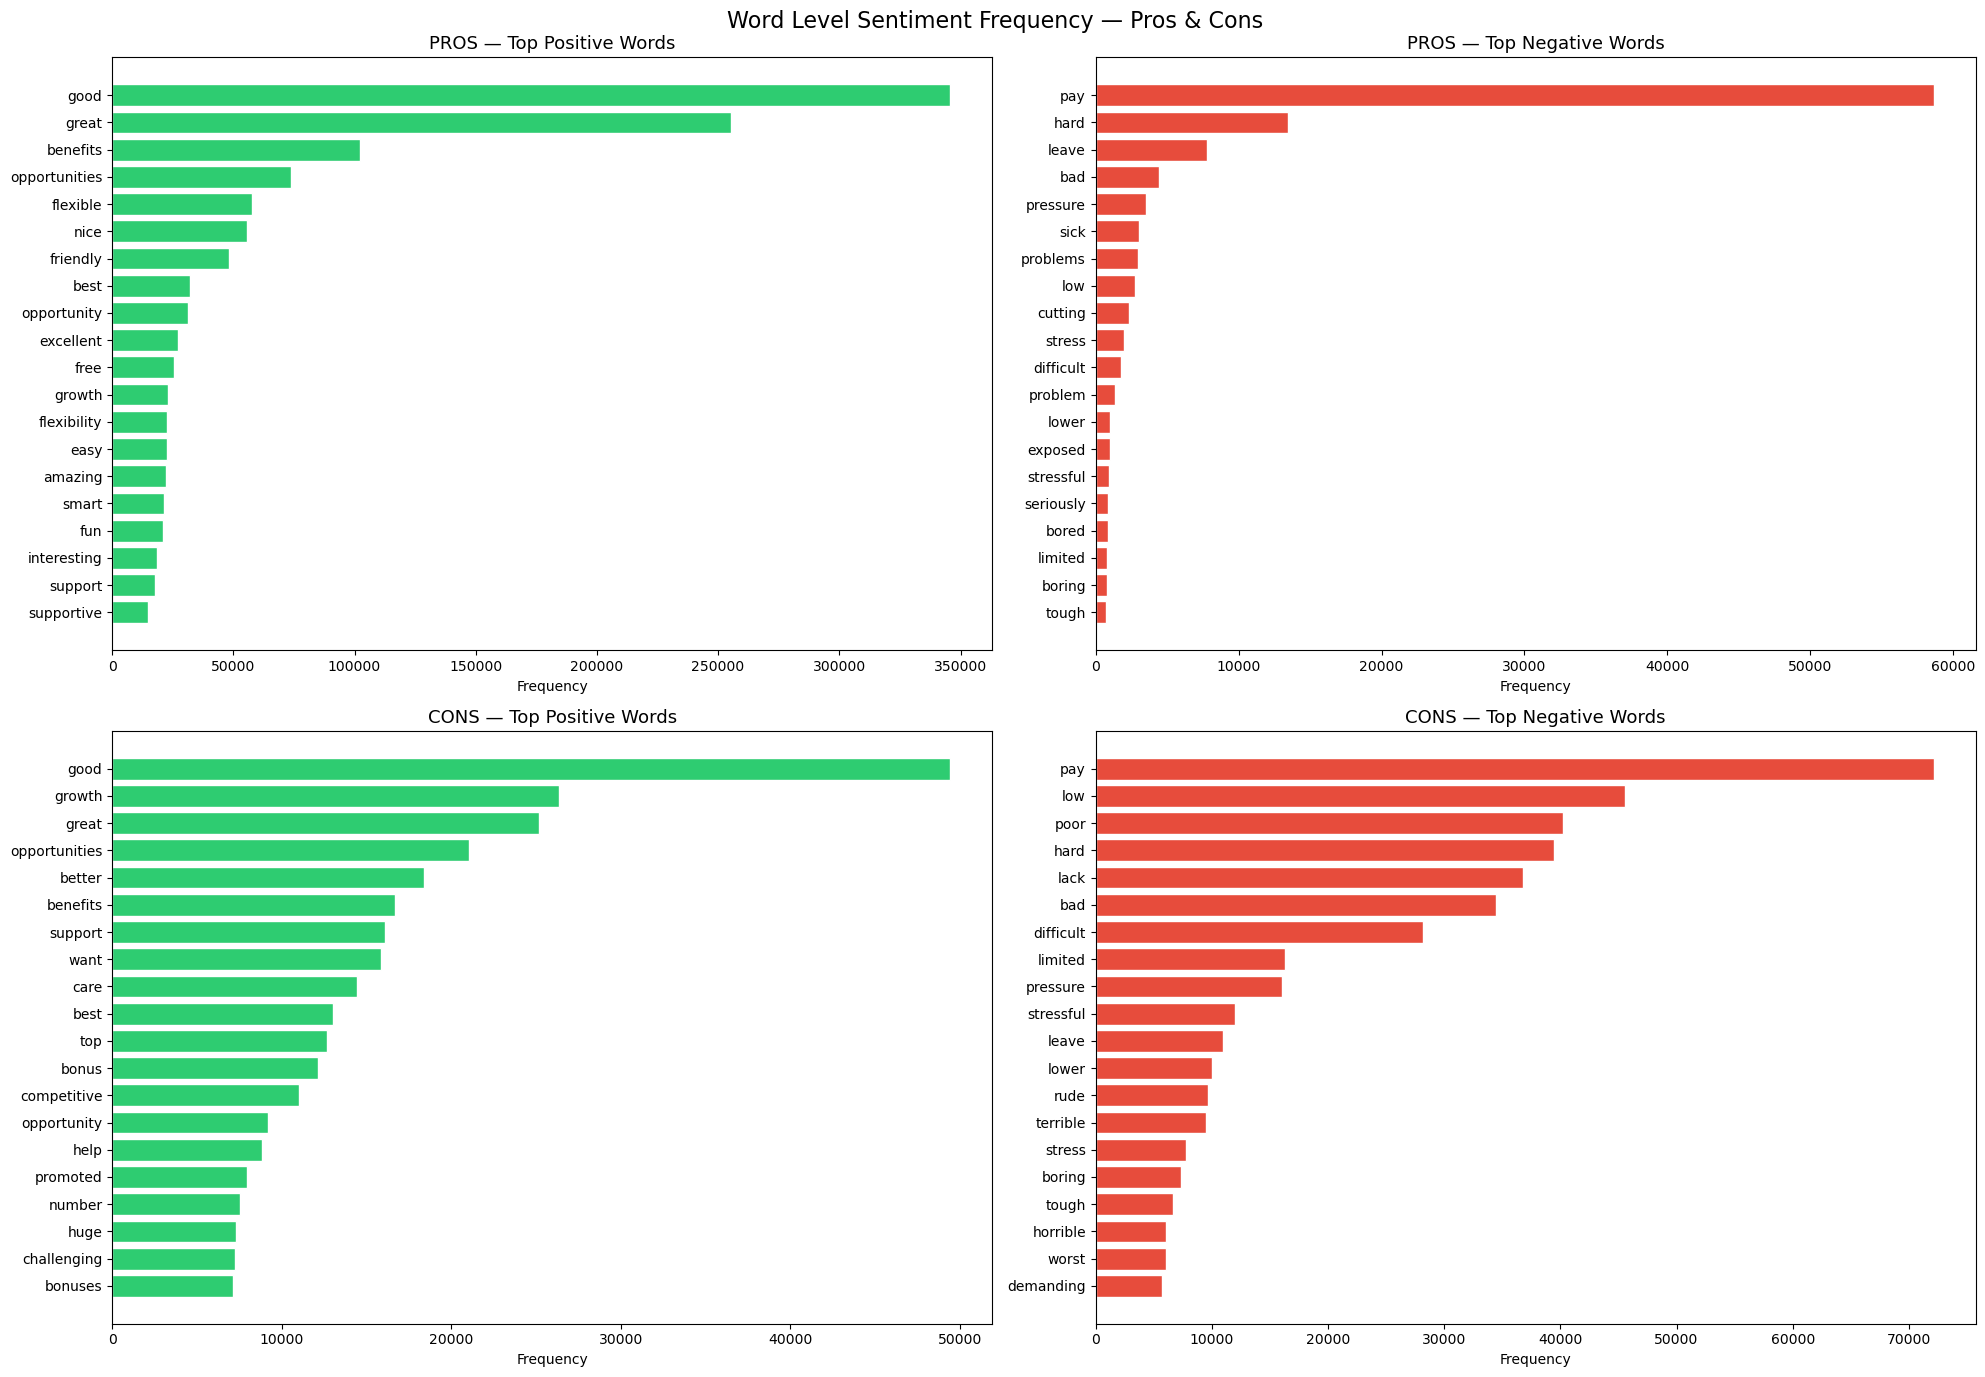

In [65]:

analyzer = SentimentIntensityAnalyzer()

# ── Stopwords ───────
stopwords = set([
    'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on',
    'at', 'to', 'for', 'of', 'with', 'is', 'are', 'was',
    'were', 'be', 'been', 'have', 'has', 'had', 'do', 'does',
    'did', 'will', 'would', 'could', 'should', 'may', 'might',
    'not', 'no', 'its', 'it', 'this', 'that', 'very', 'so',
    'i', 'you', 'we', 'they', 'he', 'she', 'my', 'your',
    'our', 'their', 'there', 'here', 'also', 'can', 'get',
    'got', 'lot', 'much', 'more', 'some', 'many', 'most',
    'just', 'like', 'well', 'even', 'still', 'really',
    'work', 'company', 'job', 'place', 'people', 'time',
    'make', 'made', 'one', 'two', 'new', 'old', 'other',
    'than', 'then', 'when', 'where', 'which', 'who', 'how',
    'what', 'all', 'any', 'few', 'too', 'only', 'same',
    'about', 'after', 'before', 'between', 'through', 'during'
])

# STEP 1 — EXTRACT ALL WORDS + THEIR FREQUENCY


def extract_all_words(series):
    """
    Extracts every word from the entire column
    Returns a Counter with word frequencies
    """
    all_words = []
    
    for text in series.dropna():
        text = str(text).lower().strip()
        if text == "":
            continue
        words = re.findall(r'\b[a-z]{3,}\b', text)
        # Remove stopwords
        words = [w for w in words if w not in stopwords]
        all_words.extend(words)
    
    return Counter(all_words)

# print("=" * 60)
print("EXTRACTING ALL WORDS FROM PROS & CONS")
# print("=" * 60)

print("\nExtracting from pros...")
pros_word_freq  = extract_all_words(Review['pros_clean'])
print(f"Unique words in pros : {len(pros_word_freq):,}")

print("\nExtracting from cons...")
cons_word_freq  = extract_all_words(Review['cons_clean'])
print(f"Unique words in cons : {len(cons_word_freq):,}")


# STEP 2 — LOOP THROUGH EVERY WORD & GET ITS SENTIMENT

def get_word_sentiment_label(word):
    """
    Gets VADER sentiment for a single word
    Returns Positive / Neutral / Negative
    """
    score = analyzer.polarity_scores(word)['compound']
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

def build_word_sentiment_df(word_freq, col_name):
    """
    Loops through EVERY unique word
    Gets its frequency + sentiment
    Returns a sorted DataFrame
    """
    print(f"\nBuilding sentiment for all words in {col_name}...")
    
    rows = []
    total = len(word_freq)
    
    for idx, (word, count) in enumerate(word_freq.items()):
        
        # Progress update every 1000 words
        if idx % 1000 == 0:
            print(f"  Processing word {idx:,} / {total:,}...", 
                  end='\r')
        
        # Get sentiment for this word
        score = analyzer.polarity_scores(word)['compound']
        
        if score >= 0.05:
            label = 'Positive'
        elif score <= -0.05:
            label = 'Negative'
        else:
            label = 'Neutral'
        
        rows.append({
            'word'      : word,
            'frequency' : count,
            'score'     : round(score, 4),
            'sentiment' : label
        })
    
    # Build dataframe
    df = pd.DataFrame(rows)
    
    # Sort by frequency (most common first)
    df = df.sort_values('frequency', ascending=False)
    df = df.reset_index(drop=True)
    df.index += 1  # start rank from 1
    
    print(f"\n  Done! Total unique words processed : {total:,}")
    return df

# ── Build for pros ───────────────────────────────────────────
pros_word_df = build_word_sentiment_df(pros_word_freq, 'PROS')

# ── Build for cons ───────────────────────────────────────────
cons_word_df = build_word_sentiment_df(cons_word_freq, 'CONS')


# STEP 3 — VIEW RESULTS

print("\n" + "=" * 60)
print("PROS — ALL WORDS WITH SENTIMENT")
print("=" * 60)
print(f"\nTotal unique words : {len(pros_word_df):,}")
print(f"\n{pros_word_df.to_string()}")

print("\n" + "=" * 60)
print("CONS — ALL WORDS WITH SENTIMENT")
print("=" * 60)
print(f"\nTotal unique words : {len(cons_word_df):,}")
print(f"\n{cons_word_df.to_string()}")

# ============================================================
# STEP 4 — FILTER BY SENTIMENT LABEL
# ============================================================

print("\n" + "=" * 60)
print("PROS — WORDS BY SENTIMENT CATEGORY")
print("=" * 60)

for label in ['Positive', 'Negative', 'Neutral']:
    filtered = pros_word_df[
        pros_word_df['sentiment'] == label
    ].head(30)
    print(f"\n>>> {label} words in PROS (top 30 by frequency):")
    print(filtered[['word', 'frequency', 'score']].to_string())

print("\n" + "=" * 60)
print("CONS — WORDS BY SENTIMENT CATEGORY")
print("=" * 60)

for label in ['Positive', 'Negative', 'Neutral']:
    filtered = cons_word_df[
        cons_word_df['sentiment'] == label
    ].head(30)
    print(f"\n>>> {label} words in CONS (top 30 by frequency):")
    print(filtered[['word', 'frequency', 'score']].to_string())

# ============================================================
# STEP 5 — SUMMARY COUNT PER SENTIMENT
# ============================================================

print("\n" + "=" * 60)
print("SUMMARY — HOW MANY WORDS PER SENTIMENT")
print("=" * 60)

print("\nPROS word sentiment breakdown:")
print(pros_word_df['sentiment'].value_counts())
print(pros_word_df.groupby('sentiment')['frequency'].sum())

print("\nCONS word sentiment breakdown:")
print(cons_word_df['sentiment'].value_counts())
print(cons_word_df.groupby('sentiment')['frequency'].sum())

# ============================================================
# STEP 6 — VISUALIZE
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# ── Pros top positive words ───────────────────────────────────
pros_pos = pros_word_df[
    pros_word_df['sentiment'] == 'Positive'
].head(20)
axes[0,0].barh(
    pros_pos['word'][::-1],
    pros_pos['frequency'][::-1],
    color='#2ecc71', edgecolor='white'
)
axes[0,0].set_title('PROS — Top Positive Words', fontsize=13)
axes[0,0].set_xlabel('Frequency')

# ── Pros top negative words ───────────────────────────────────
pros_neg = pros_word_df[
    pros_word_df['sentiment'] == 'Negative'
].head(20)
axes[0,1].barh(
    pros_neg['word'][::-1],
    pros_neg['frequency'][::-1],
    color='#e74c3c', edgecolor='white'
)
axes[0,1].set_title('PROS — Top Negative Words', fontsize=13)
axes[0,1].set_xlabel('Frequency')

# ── Cons top positive words ───────────────────────────────────
cons_pos = cons_word_df[
    cons_word_df['sentiment'] == 'Positive'
].head(20)
axes[1,0].barh(
    cons_pos['word'][::-1],
    cons_pos['frequency'][::-1],
    color='#2ecc71', edgecolor='white'
)
axes[1,0].set_title('CONS — Top Positive Words', fontsize=13)
axes[1,0].set_xlabel('Frequency')

# ── Cons top negative words ───────────────────────────────────

cons_neg = cons_word_df[
    cons_word_df['sentiment'] == 'Negative'
].head(20)
axes[1,1].barh(
    cons_neg['word'][::-1],
    cons_neg['frequency'][::-1],
    color='#e74c3c', edgecolor='white'
)
axes[1,1].set_title('CONS — Top Negative Words', fontsize=13)
axes[1,1].set_xlabel('Frequency')

plt.suptitle(
    'Word Level Sentiment Frequency — Pros & Cons',
    fontsize=16
)
plt.tight_layout()
plt.show()


# # STEP 7 — SAVE RESULTS

# # Save to csv so you can view all words easily
# pros_word_df.to_csv('pros_word_sentiment.csv')
# cons_word_df.to_csv('cons_word_sentiment.csv')
# print("\nSaved to pros_word_sentiment.csv")
# print("Saved to cons_word_sentiment.csv")

In [66]:
# print(pros_word_df)

In [67]:
# print(Review['headline_clean'])

### Considering headline to check the overall sentiment of employee

>>> Running VADER on headlines...


  Sentiment [headline]: 100%|███████████████████████████████████████████████████████| 84/84 [00:34<00:00,  2.46chunk/s]


Done 

>>> Detecting headline patterns...


  Pattern [headline]: 100%|█████████████████████████████████████████████████████████| 84/84 [00:06<00:00, 12.55chunk/s]


Done...

HEADLINE SENTIMENT RESULTS

>>> VADER Sentiment Distribution:
headline_sentiment
Positive    386649
Neutral     373286
Negative     78631
Name: count, dtype: int64
headline_sentiment
Positive    46.1
Neutral     44.5
Negative     9.4
Name: proportion, dtype: float64

>>> Pattern Distribution:
headline_pattern
Neutral     469681
Positive    271302
Negative     65337
Mixed        32246
Name: count, dtype: int64
headline_pattern
Neutral     56.0
Positive    32.4
Negative     7.8
Mixed        3.8
Name: proportion, dtype: float64

>>> Average headline score : 0.206


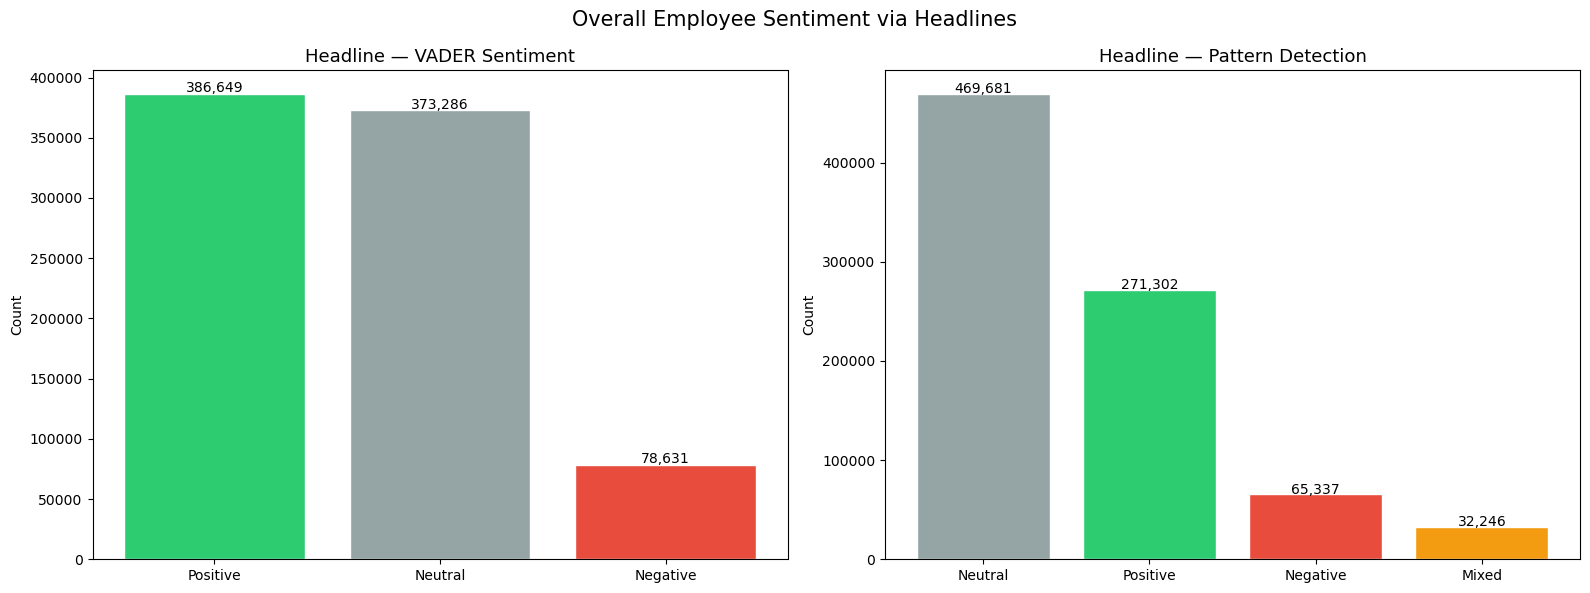


SAMPLE HEADLINES PER SENTIMENT

Positive headlines (sample 5):
   — good place to work
   — good place to work
   — best place to work!
   — great place to work with a nice team of people. if you want to progress the opportunities are there for you.
   — positive experience

Negative headlines (sample 5):
   — young colleagues, poor micro management
   — low salary, bad micromanagement
   — it horrible management
   — avoid at all cost
   — worst place i have ever worked

Mixed headlines (sample 5):
   — excellent staff, poor salary
   — great for people, not for work
   — employees have only little to say to get things done and there's not enough of resources to be able to do good job
   — tunbridge wells office - only good for first-jobbers otherwise avoid
   — great colleagues, horrible bosses.

Neutral headlines (sample 5):
   — over promised under delivered
   — client reporting admin
   — office administrator
   — i liked working for afh
   — honest review


In [80]:

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt

analyzer = SentimentIntensityAnalyzer()

# ── VADER Score & Label ──────────────────────────

def get_headline_score(text):
    if pd.isnull(text) or str(text).strip() == "":
        return 0.0
    return round(
        analyzer.polarity_scores(str(text))['compound'], 4
    )

def get_headline_sentiment(text):
    if pd.isnull(text) or str(text).strip() == "":
        return 'Neutral'
    score = analyzer.polarity_scores(str(text))['compound']
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

print(">>> Running VADER on headlines...")
Review['headline_score'] = process_in_chunks(
    Review, 'headline_clean',
    get_headline_score,
    label="  Score     [headline]"
)
Review['headline_sentiment'] = process_in_chunks(
    Review, 'headline_clean',
    get_headline_sentiment,
    label="  Sentiment [headline]"
)
print("Done ")

# ── Pattern Detection ────────────────────────────

positive_words = [
    'great', 'good', 'excellent', 'amazing', 'awesome',
    'fantastic', 'wonderful', 'best', 'love', 'enjoy',
    'friendly', 'helpful', 'positive', 'recommend',
    'perfect', 'outstanding', 'brilliant', 'superb'
]

negative_words = [
    'poor', 'bad', 'terrible', 'awful', 'worst',
    'toxic', 'horrible', 'disappointing', 'avoid',
    'low', 'no', 'lack', 'problem', 'issue',
    'difficult', 'stressful', 'overworked', 'underpaid'
]

def detect_pattern(text):
    """
    Mixed    → has BOTH positive and negative words
               "excellent staff, poor salary"
    Positive → only positive words
               "great place to work"
    Negative → only negative words
               "toxic culture, no growth"
    Neutral  → no clear sentiment words
               "client reporting admin"
    """
    if pd.isnull(text) or str(text).strip() == "":
        return 'Neutral'
    
    text         = str(text).lower()
    has_positive = any(w in text for w in positive_words)
    has_negative = any(w in text for w in negative_words)
    
    if has_positive and has_negative:
        return 'Mixed'
    elif has_positive:
        return 'Positive'
    elif has_negative:
        return 'Negative'
    else:
        return 'Neutral'

print("\n>>> Detecting headline patterns...")
Review['headline_pattern'] = process_in_chunks(
    Review, 'headline_clean',
    detect_pattern,
    label="  Pattern [headline]"
)
print("Done...")

# ── RESULTS ───────────────────────────────────────────────────
print("\n" + "=" * 60)
print("HEADLINE SENTIMENT RESULTS")
print("=" * 60)

print("\n>>> VADER Sentiment Distribution:")
print(Review['headline_sentiment'].value_counts())
print(Review['headline_sentiment'].value_counts(
    normalize=True).mul(100).round(1))

print("\n>>> Pattern Distribution:")
print(Review['headline_pattern'].value_counts())
print(Review['headline_pattern'].value_counts(
    normalize=True).mul(100).round(1))

print(f"\n>>> Average headline score : "
      f"{Review['headline_score'].mean():.3f}")

# ── VISUALIZATION ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# VADER sentiment
hl_sentiment = Review['headline_sentiment'].value_counts()
colors_s = {
    'Positive': '#2ecc71',
    'Negative': '#e74c3c',
    'Neutral' : '#95a5a6'
}
axes[0].bar(
    hl_sentiment.index,
    hl_sentiment.values,
    color=[colors_s.get(l, 'steelblue') 
           for l in hl_sentiment.index],
    edgecolor='white'
)
axes[0].set_title('Headline — VADER Sentiment', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(hl_sentiment.values):
    axes[0].text(i, v + 1000, f'{v:,}',
                 ha='center', fontsize=10)

# Pattern detection
hl_pattern = Review['headline_pattern'].value_counts()
colors_p = {
    'Positive': '#2ecc71',
    'Negative': '#e74c3c',
    'Mixed'   : '#f39c12',
    'Neutral' : '#95a5a6'
}
axes[1].bar(
    hl_pattern.index,
    hl_pattern.values,
    color=[colors_p.get(l, 'steelblue') 
           for l in hl_pattern.index],
    edgecolor='white'
)
axes[1].set_title('Headline — Pattern Detection', fontsize=13)
axes[1].set_ylabel('Count')
for i, v in enumerate(hl_pattern.values):
    axes[1].text(i, v + 1000, f'{v:,}',
                 ha='center', fontsize=10)

plt.suptitle(
    'Overall Employee Sentiment via Headlines',
    fontsize=15
)
plt.tight_layout()
plt.show()

# ── SAMPLE HEADLINES PER CATEGORY ────────────────────────────
print("\n" + "=" * 60)
print("SAMPLE HEADLINES PER SENTIMENT")
print("=" * 60)

for label in ['Positive', 'Negative', 'Mixed', 'Neutral']:
    print(f"\n{label} headlines (sample 5):")
    
    sample = Review[
        Review['headline_pattern'] == label
    ]['headline_clean'].dropna().head(5)
    
    for h in sample:
        print(f"   — {h}")

In [81]:
print(Review.columns.tolist())

['firm', 'date_review', 'job_title', 'current', 'location', 'overall_rating', 'work_life_balance', 'culture_values', 'career_opp', 'comp_benefits', 'senior_mgmt', 'recommend_custom', 'ceo_approval_custom', 'outlook_custom', 'headline', 'pros', 'cons', 'year', 'month', 'day', 'city', 'region', 'country', 'Rating_Bucket_WLB', 'employee_status', 'timeduration', 'Experience', 'pros_clean', 'cons_clean', 'headline_clean', 'employee_status_bucket', 'headline_score', 'headline_sentiment', 'headline_pattern']


In [82]:
# Review[Review['headline_sentiment'] == 'Negative']
# Review[Review['headline_sentiment'] == 'Positive']


In [83]:
# print(Review.columns.tolist())

In [84]:
print(Review['recommend_custom'].value_counts())
print(Review['outlook_custom'].value_counts())
print(Review['employee_status'].value_counts())

print(Review['Experience'].value_counts())

recommend_custom
positive      427865
no opinion    234248
negative      176453
Name: count, dtype: int64
outlook_custom
positive      301413
no opinion    294548
average       154948
negative       87657
Name: count, dtype: int64
employee_status
Current Employee             492112
Former Employee              346425
Former Contractor                10
Former Intern                     8
Current Contractor                8
Current Intern                    1
Former Temporary Employee         1
Current Freelancer                1
Name: count, dtype: int64
Experience
>1     148441
>3     110086
<1      91492
>5      63172
>10     40440
>8      29193
Name: count, dtype: int64


### 
These are NOT real employee statuses
They are SYSTEM ERRORS from backend where the job type code could not be mapped to a readable label 
per_diem  → means "per day" worker (daily wage)
temporary → means temporary worker
Both are FORMER employees based on "-former" suffix
 so we are mapping accordingly

In [85]:

key_not_found_map = {
    'KEY NOT FOUND: jobLine.per_diem-former'  : 'Former Employee',
    'KEY NOT FOUND: jobLine.temporary-former' : 'Former Employee'
}

Review['employee_status'] = Review['employee_status'].replace(
    key_not_found_map
)

print("KEY NOT FOUND entries fixed ")
print(Review['employee_status'].value_counts())

KEY NOT FOUND entries fixed 
employee_status
Current Employee             492112
Former Employee              346425
Former Contractor                10
Former Intern                     8
Current Contractor                8
Current Intern                    1
Former Temporary Employee         1
Current Freelancer                1
Name: count, dtype: int64


In [86]:
# Too many small categories make analysis messy
# Consolidate into 2 clean buckets

status_map = {
    # Current group
    'Current Employee'    : 'Current',
    'Current Contractor'  : 'Current',
    'Current Intern'      : 'Current',
    'Current Freelancer'  : 'Current',

    # Former group
    'Former Employee'          : 'Former',
    'Former Contractor'        : 'Former',
    'Former Intern'            : 'Former',
    'Former Temporary Employee': 'Former',
}

Review['employee_status_bucket'] = Review[
    'employee_status'
].map(status_map)

# Check for any unmapped values
unmapped = Review[
    Review['employee_status_bucket'].isnull()
]['employee_status'].unique()
print(f"Unmapped values : {unmapped}")

print("\nFinal distribution:")
print(Review['employee_status_bucket'].value_counts())


Unmapped values : []

Final distribution:
employee_status_bucket
Current    492122
Former     346444
Name: count, dtype: int64


In [87]:
# Review[Review['employee_status_bucket'] == 'Former']['employee_status'].value_counts

In [88]:
# Final check

print("EMPLOYEE STATUS — FINAL SUMMARY")

print("\nDetailed (original cleaned):")
print(Review['employee_status'].value_counts())

print("\nBucketed (for KPI):")
print(Review['employee_status_bucket'].value_counts())
print(Review['employee_status_bucket'].value_counts(
    normalize=True).mul(100).round(1))


EMPLOYEE STATUS — FINAL SUMMARY

Detailed (original cleaned):
employee_status
Current Employee             492112
Former Employee              346425
Former Contractor                10
Former Intern                     8
Current Contractor                8
Current Intern                    1
Former Temporary Employee         1
Current Freelancer                1
Name: count, dtype: int64

Bucketed (for KPI):
employee_status_bucket
Current    492122
Former     346444
Name: count, dtype: int64
employee_status_bucket
Current    58.7
Former     41.3
Name: proportion, dtype: float64


In [89]:
# Quick EDA example using the bucket
print("\nAvg overall_rating by employee status:")
print(Review.groupby('employee_status_bucket')[
    'overall_rating'
].mean().round(2))


Avg overall_rating by employee status:
employee_status_bucket
Current    3.81
Former     3.44
Name: overall_rating, dtype: float64


In [90]:
# print(Review.columns.tolist())
print("\n>>> Running VADER on PROS...")

Review['pros_score'] = process_in_chunks(
    Review, 'pros_clean',
    get_headline_score,
    label="  Score     [pros]"
)

Review['pros_sentiment'] = process_in_chunks(
    Review, 'pros_clean',
    get_headline_sentiment,
    label="  Sentiment [pros]"
)


>>> Running VADER on PROS...


  Sentiment [pros]: 100%|███████████████████████████████████████████████████████████| 84/84 [02:16<00:00,  1.63s/chunk]


In [92]:
print("\n>>> Running VADER on CONS...")

Review['cons_score'] = process_in_chunks(
    Review, 'cons_clean',
    get_headline_score,
    label="  Score     [cons]"
)

Review['cons_sentiment'] = process_in_chunks(
    Review, 'cons_clean',
    get_headline_sentiment,
    label="  Sentiment [cons]"
)


>>> Running VADER on CONS...


  Sentiment [cons]: 100%|███████████████████████████████████████████████████████████| 84/84 [03:32<00:00,  2.53s/chunk]


In [93]:
sentiment_map = {
    'Positive': 1,
    'Neutral' : 0,
    'Negative': -1
}

Review['pros_sentiment_score'] = Review['pros_sentiment'].map(sentiment_map)
Review['cons_sentiment_score'] = Review['cons_sentiment'].map(sentiment_map)

In [94]:

# import warnings
# warnings.filterwarnings('ignore')


print("SECTION 1 — FIRM HEALTH KPIs")


# ── KPI 1: Overall Firm Score ──────────────────────────
print("\n KPI 1: Overall Firm Score")

rating_cols = [
    'overall_rating', 'work_life_balance', 'culture_values',
    'career_opp', 'comp_benefits', 'senior_mgmt'
]

firm_overall_score = (
    Review.groupby('firm')[rating_cols]
    .mean()
    .round(2)
)
firm_overall_score['Overall_Firm_Score'] = (
    firm_overall_score[rating_cols].mean(axis=1).round(2)
)
firm_overall_score = firm_overall_score.sort_values(
    'Overall_Firm_Score', ascending=False
)

print(f"\nTop 10 firms by Overall Firm Score:")
print(firm_overall_score[['Overall_Firm_Score']].head(10))
print(f"\nBottom 10 firms by Overall Firm Score:")
print(firm_overall_score[['Overall_Firm_Score']].tail(10))


# ── KPI 2: Employee Satisfaction Index ───────────────────────
print("\n KPI 2: Employee Satisfaction Index")

satisfaction_index = (
    Review.groupby('firm')['pros_sentiment_score']
    .mean()
    .round(3)
    .sort_values(ascending=False)
)

print(f"\nTop 10 firms by Satisfaction Index:")
print(satisfaction_index.head(10))
print(f"\nBottom 10 firms by Satisfaction Index:")
print(satisfaction_index.tail(10))

# ── KPI 3: Complaint Intensity Score ─────────────────────────
print("\n KPI 3: Complaint Intensity Score")

complaint_score = (
    Review.groupby('firm')['cons_score']
    .mean()
    # .mul(-1)   # flip so higher = worse
    .round(3)
    .sort_values(ascending=False)
    .rename('Complaint_Intensity_Score')
)
print(f"\nTop 10 most complained firms:")
print(complaint_score.head(10))


SECTION 1 — FIRM HEALTH KPIs

 KPI 1: Overall Firm Score

Top 10 firms by Overall Firm Score:
                        Overall_Firm_Score
firm                                      
Northern-Gas-and-Power                4.68
Time-Etc                              4.63
CarShop-UK                            4.44
Kingsley-Healthcare                   4.38
Michelmores                           4.37
Gateley                               4.27
Anglian-Water                         4.26
Taylor-Wimpey                         4.25
Abcam                                 4.25
Wise                                  4.25

Bottom 10 firms by Overall Firm Score:
                              Overall_Firm_Score
firm                                            
Curtis-Banks                                2.53
HM-Prison-Service                           2.53
UKCIL                                       2.50
Link-Group                                  2.47
James-Hay-Partnership                       2.42
Diligen

In [ ]:

# # ── KPI 7: Review Sentiment Gap ──────────────────────────────
# print("\n>>> KPI 7: Review Sentiment Gap (Pros - Cons)")

# sentiment_map = {
#     'Positive': 1,
#     'Neutral': 0,
#     'Negative': -1
# }

# Review['pros_sentiment_num'] = Review['pros_sentiment_label'].map(sentiment_map)
# Review['cons_sentiment_num'] = Review['cons_sentiment_label'].map(sentiment_map)

# sentiment_gap = (
#     Review.groupby('firm')
#     .apply(lambda x: round(
#         x['pros_sentiment_num'].mean() - x['cons_sentiment_num'].mean(), 3
#     ))
#     .sort_values(ascending=False)
# )

# print(f"\nTop 10 firms with highest sentiment gap:")
# print(sentiment_gap.head(10))
# print(f"\nBottom 10 firms with lowest sentiment gap:")
# print(sentiment_gap.tail(10))

# # ============================================================
# # SECTION 2 — EMPLOYEE EXPERIENCE KPIs
# # ============================================================
# print("\n" + "=" * 60)
# print("SECTION 2 — EMPLOYEE EXPERIENCE KPIs")
# print("=" * 60)

# # ── KPI 8: All Experience Sub Scores by Firm ─────────────────
# print("\n>>> KPI 8: Employee Experience Sub Scores")

# experience_kpis = Review.groupby('firm').agg(
#     WLB_Score        = ('work_life_balance', 'mean'),
#     Career_Score     = ('career_opp',        'mean'),
#     Culture_Score    = ('culture_values',    'mean'),
#     Comp_Score       = ('comp_benefits',     'mean'),
#     Mgmt_Score       = ('senior_mgmt',       'mean')
# ).round(2)

# print(f"\nTop 10 firms — All Experience KPIs:")
# print(experience_kpis.sort_values(
#     'Culture_Score', ascending=False
# ).head(10))

# # ── KPI 9: Retention Risk Score ──────────────────────────────
# print("\n>>> KPI 9: Retention Risk Score")

# # % of former employees with negative sentiment
# def retention_risk(group):
#     former   = group[group['employee_status_bucket'] == 'Former']
#     if len(former) == 0:
#         return np.nan
#     negative = (former['cons_sentiment_label'] == 'Negative').sum()
#     return round(negative / len(former) * 100, 1)

# retention_risk_score = (
#     Review.groupby('firm')
#     .apply(retention_risk)
#     .sort_values(ascending=False)
#     .rename('Retention_Risk_%')
# )

# print(f"\nTop 10 high retention risk firms:")
# print(retention_risk_score.head(10))

# # ============================================================
# # SECTION 3 — SENTIMENT KPIs
# # ============================================================
# print("\n" + "=" * 60)
# print("SECTION 3 — SENTIMENT KPIs")
# print("=" * 60)

# # ── KPI 10: Positive/Negative/Mixed Review Rates ─────────────
# print("\n>>> KPI 10: Review Rate KPIs")

# total = len(Review)

# positive_rate = (
#     Review['headline_sentiment_label'] == 'Positive'
# ).sum() / total * 100

# negative_rate = (
#     Review['headline_sentiment_label'] == 'Negative'
# ).sum() / total * 100

# mixed_rate = (
#     Review['headline_pattern'] == 'Mixed'
# ).sum() / total * 100

# avg_headline  = Review['headline_score'].mean()
# pros_pos_rate = (
#     Review['pros_sentiment_label'] == 'Positive'
# ).sum() / total * 100

# cons_neg_rate = (
#     Review['cons_sentiment_label'] == 'Negative'
# ).sum() / total * 100

# sentiment_kpis = pd.DataFrame({
#     'KPI'  : [
#         'Positive Review Rate %',
#         'Negative Review Rate %',
#         'Mixed Review Rate %',
#         'Avg Headline Score',
#         'Pros Positivity Rate %',
#         'Cons Negativity Rate %'
#     ],
#     'Value': [
#         round(positive_rate, 1),
#         round(negative_rate, 1),
#         round(mixed_rate,    1),
#         round(avg_headline,  3),
#         round(pros_pos_rate, 1),
#         round(cons_neg_rate, 1)
#     ]
# })

# print(f"\n{sentiment_kpis.to_string(index=False)}")

# # ============================================================
# # SECTION 4 — TIME BASED KPIs
# # ============================================================
# print("\n" + "=" * 60)
# print("SECTION 4 — TIME BASED KPIs")
# print("=" * 60)

# # ── KPI 11: YoY Rating Change ─────────────────────────────────
# print("\n>>> KPI 11: Year over Year Rating Change")

# yoy_rating = (
#     Review.groupby('year')['overall_rating']
#     .mean()
#     .round(2)
# )
# yoy_rating_change = yoy_rating.diff().round(2)

# yoy_df = pd.DataFrame({
#     'Avg_Rating'    : yoy_rating,
#     'YoY_Change'    : yoy_rating_change
# })
# print(f"\n{yoy_df.to_string()}")

# # ── KPI 12: YoY Sentiment Change ─────────────────────────────
# print("\n>>> KPI 12: Year over Year Sentiment Change")

# yoy_sentiment = (
#     Review.groupby('year')['headline_score']
#     .mean()
#     .round(3)
# )
# yoy_sentiment_change = yoy_sentiment.diff().round(3)

# yoy_sent_df = pd.DataFrame({
#     'Avg_Sentiment' : yoy_sentiment,
#     'YoY_Change'    : yoy_sentiment_change
# })
# print(f"\n{yoy_sent_df.to_string()}")

# # ── KPI 13: Review Volume Growth ─────────────────────────────
# print("\n>>> KPI 13: Review Volume Growth")

# volume = Review.groupby('year').size().rename('Review_Count')
# volume_growth = volume.pct_change().mul(100).round(1).rename(
#     'Growth_%'
# )

# volume_df = pd.DataFrame({
#     'Review_Count' : volume,
#     'Growth_%'     : volume_growth
# })
# print(f"\n{volume_df.to_string()}")

# # ── KPI 14: Peak Complaint Period ────────────────────────────
# print("\n>>> KPI 14: Peak Complaint Period")

# peak_complaint = (
#     Review.groupby(['year', 'month'])['cons_sentiment']
#     .mean()
#     .round(3)
#     .reset_index()
#     .sort_values('cons_sentiment', ascending=True)
#     .head(10)
# )
# peak_complaint.columns = ['Year', 'Month', 
#                            'Avg_Cons_Sentiment']
# print(f"\nTop 10 most negative periods:")
# print(peak_complaint.to_string(index=False))

# # ============================================================
# # SECTION 5 — MASTER KPI DASHBOARD
# # ============================================================
# print("\n" + "=" * 60)
# print("SECTION 5 — MASTER KPI DASHBOARD")
# print("=" * 60)

# master_kpi = Review.groupby('firm').agg(
#     # Ratings
#     Overall_Score      = ('overall_rating',    'mean'),
#     WLB_Score          = ('work_life_balance',  'mean'),
#     Career_Score       = ('career_opp',         'mean'),
#     Culture_Score      = ('culture_values',     'mean'),
#     Comp_Score         = ('comp_benefits',      'mean'),
#     Mgmt_Score         = ('senior_mgmt',        'mean'),
#     # Sentiment
#     Pros_Sentiment     = ('pros_sentiment',     'mean'),
#     Cons_Sentiment     = ('cons_sentiment',     'mean'),
#     Headline_Score     = ('headline_score',     'mean'),
#     # Volume
#     Total_Reviews      = ('overall_rating',     'count')
# ).round(2)

# # Add calculated KPIs
# master_kpi['Sentiment_Gap'] = (
#     master_kpi['Pros_Sentiment'] -
#     master_kpi['Cons_Sentiment']
# ).round(2)

# master_kpi['Firm_Health_Score'] = (
#     master_kpi[[
#         'Overall_Score', 'WLB_Score',
#         'Career_Score',  'Culture_Score',
#         'Comp_Score',    'Mgmt_Score'
#     ]].mean(axis=1)
# ).round(2)

# master_kpi = master_kpi.sort_values(
#     'Firm_Health_Score', ascending=False
# )

# print(f"\nMaster KPI Dashboard (Top 15 firms):")
# print(master_kpi.head(15).to_string())

# # ── Save master KPI to Review context ────────────────────────
# print(f"\nMaster KPI shape : {master_kpi.shape}")
# print(f"Total firms      : {len(master_kpi)}")

# # ============================================================
# # SECTION 6 — VISUALIZE KEY KPIs
# # ============================================================
# print("\n" + "=" * 60)
# print("SECTION 6 — KPI VISUALIZATION")
# print("=" * 60)

# fig, axes = plt.subplots(2, 3, figsize=(22, 12))

# # ── Plot 1: Top 10 firms by Overall Score ────────────────────
# top10 = master_kpi.head(10)
# axes[0,0].barh(
#     top10.index[::-1],
#     top10['Firm_Health_Score'][::-1],
#     color='#2ecc71', edgecolor='white'
# )
# axes[0,0].set_title('Top 10 Firms — Health Score', fontsize=12)
# axes[0,0].set_xlabel('Score')

# # ── Plot 2: Bottom 10 firms ───────────────────────────────────
# bot10 = master_kpi.tail(10)
# axes[0,1].barh(
#     bot10.index[::-1],
#     bot10['Firm_Health_Score'][::-1],
#     color='#e74c3c', edgecolor='white'
# )
# axes[0,1].set_title('Bottom 10 Firms — Health Score', fontsize=12)
# axes[0,1].set_xlabel('Score')

# # ── Plot 3: YoY Rating Trend ──────────────────────────────────
# axes[0,2].plot(
#     yoy_rating.index,
#     yoy_rating.values,
#     marker='o', color='steelblue', linewidth=2
# )
# axes[0,2].set_title('YoY Overall Rating Trend', fontsize=12)
# axes[0,2].set_xlabel('Year')
# axes[0,2].set_ylabel('Avg Rating')
# axes[0,2].grid(True, alpha=0.3)

# # ── Plot 4: Sentiment KPIs bar ────────────────────────────────
# axes[1,0].bar(
#     sentiment_kpis['KPI'],
#     sentiment_kpis['Value'],
#     color='steelblue', edgecolor='white'
# )
# axes[1,0].set_title('Sentiment KPIs Overview', fontsize=12)
# axes[1,0].set_ylabel('Value')
# axes[1,0].tick_params(axis='x', rotation=45)

# # ── Plot 5: Review Volume Growth ─────────────────────────────
# axes[1,1].bar(
#     volume.index,
#     volume.values,
#     color='#9b59b6', edgecolor='white'
# )
# axes[1,1].set_title('Review Volume by Year', fontsize=12)
# axes[1,1].set_xlabel('Year')
# axes[1,1].set_ylabel('Count')

# # ── Plot 6: Sentiment Gap top 10 firms ───────────────────────
# gap10 = master_kpi.nlargest(10, 'Sentiment_Gap')
# axes[1,2].barh(
#     gap10.index[::-1],
#     gap10['Sentiment_Gap'][::-1],
#     color='#f39c12', edgecolor='white'
# )
# axes[1,2].set_title('Top 10 Firms — Sentiment Gap', fontsize=12)
# axes[1,2].set_xlabel('Pros − Cons Sentiment')

# plt.suptitle('KPI Dashboard — Employee Reviews', fontsize=16)
# plt.tight_layout()
# plt.show()

In [14]:
print(Review.columns.tolist())

['firm', 'date_review', 'job_title', 'current', 'location', 'overall_rating', 'work_life_balance', 'culture_values', 'diversity_inclusion', 'career_opp', 'comp_benefits', 'senior_mgmt', 'recommend', 'ceo_approv', 'outlook', 'headline', 'pros', 'cons']


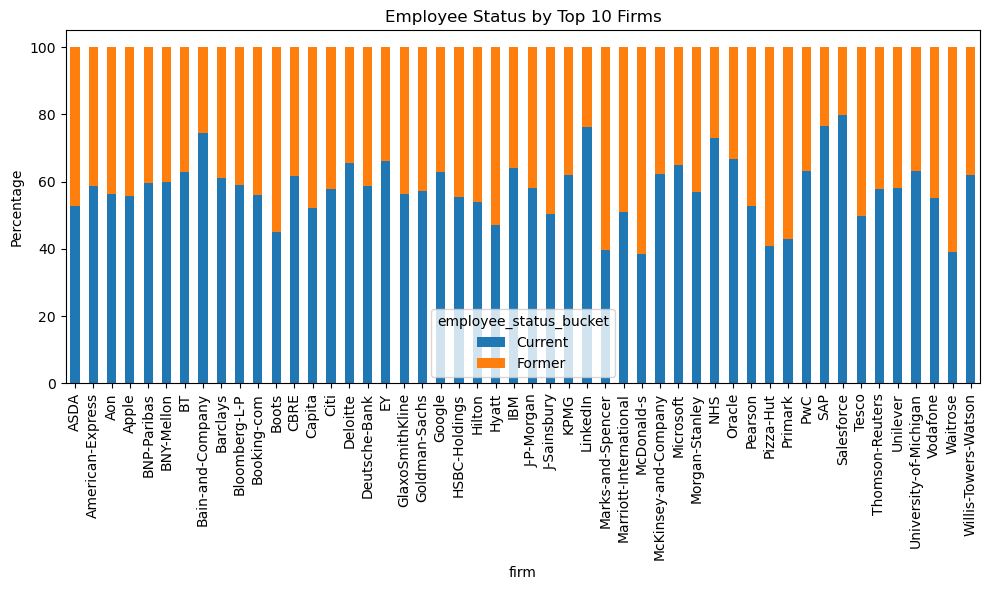

In [95]:
top_n = 50

top_firms = Review['firm'].value_counts().nlargest(top_n).index

filtered = Review[Review['firm'].isin(top_firms)]

status_counts = (
    filtered.groupby(['firm', 'employee_status_bucket'])
    .size()
    .unstack(fill_value=0)
)

status_pct = status_counts.div(status_counts.sum(axis=1), axis=0) * 100

status_pct.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title("Employee Status by Top 10 Firms")
plt.ylabel("Percentage")
# plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [96]:
import plotly.express as px

# First ensure country column is clean
df = Review.copy()

country_rating = (
    df.groupby('country')['overall_rating']
    .mean()
    .reset_index()
)

fig = px.choropleth(
    country_rating,
    locations='country',        # must be country names
    locationmode='country names',
    color='overall_rating',
    title='Average Rating by Country',
    color_continuous_scale='Blues'
)

fig.show()

C:\Users\user\AppData\Local\Temp\ipykernel_7892\3042225940.py:12: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


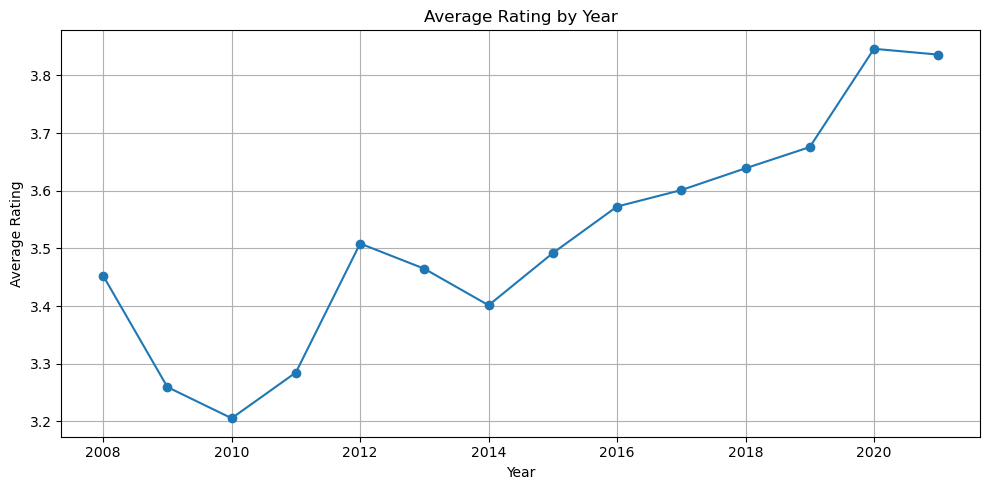

In [97]:
avg_rating = Review.groupby('year')['overall_rating'].mean()

plt.figure(figsize=(10,5))
plt.plot(avg_rating.index, avg_rating.values, marker='o')

plt.title("Average Rating by Year")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.grid()

plt.tight_layout()
plt.show()

In [98]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
Review = pd.read_csv("Review.csv")


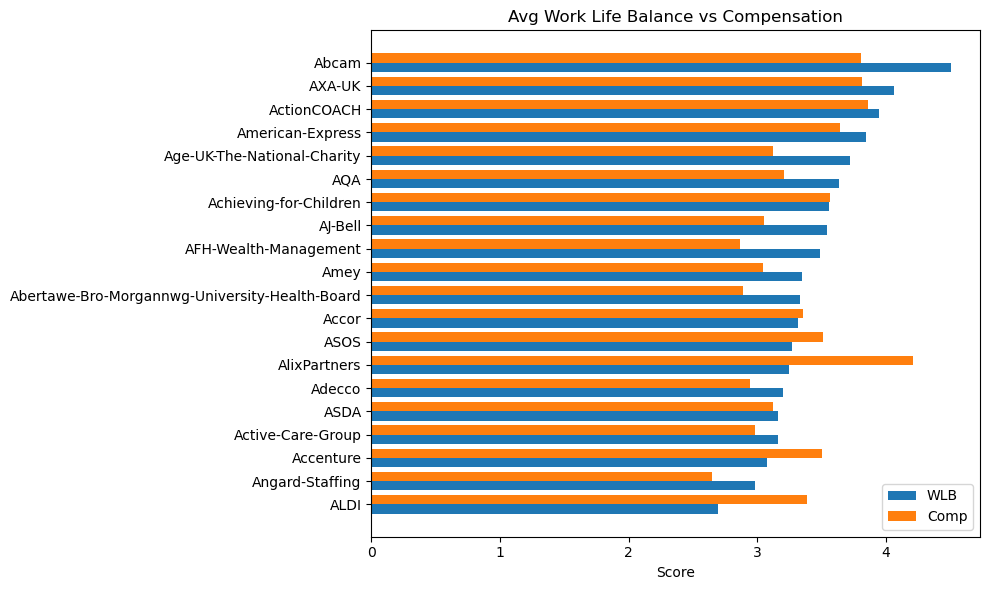

In [106]:
job_avg = Review.groupby('firm')[['work_life_balance', 'comp_benefits']].mean().head(20).reset_index()

# Sort
job_avg = job_avg.sort_values(by='work_life_balance')

y = np.arange(len(job_avg))

plt.figure(figsize=(10,6))

# Side-by-side bars
plt.barh(y - 0.2, job_avg['work_life_balance'], height=0.4, label='WLB')
plt.barh(y + 0.2, job_avg['comp_benefits'], height=0.4, label='Comp')

plt.yticks(y, job_avg['firm'])

plt.xlabel("Score")
plt.title("Avg Work Life Balance vs Compensation")
plt.legend()

plt.tight_layout()
plt.show()

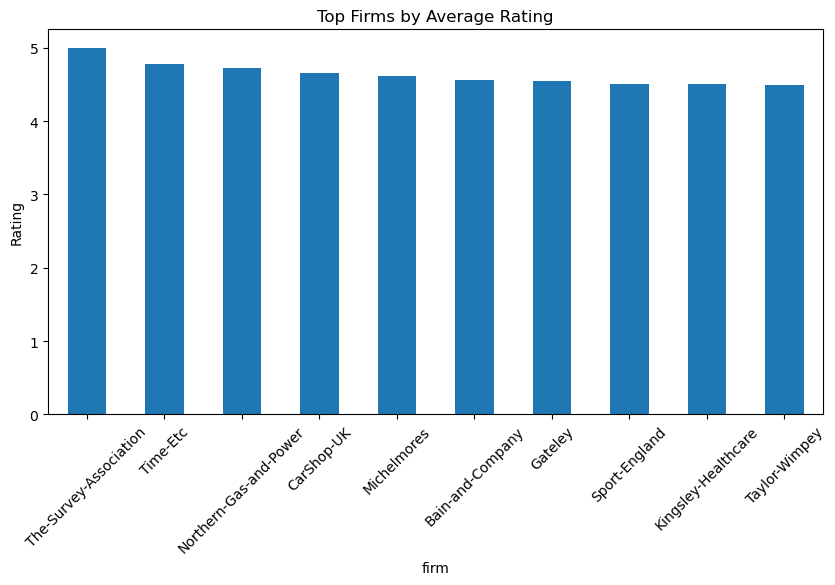

In [100]:
top_firms = (
    Review.groupby('firm')['overall_rating']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_firms.plot(kind='bar', figsize=(10,5))
plt.title("Top Firms by Average Rating")
plt.ylabel("Rating")
plt.xticks(rotation=45)
plt.show()

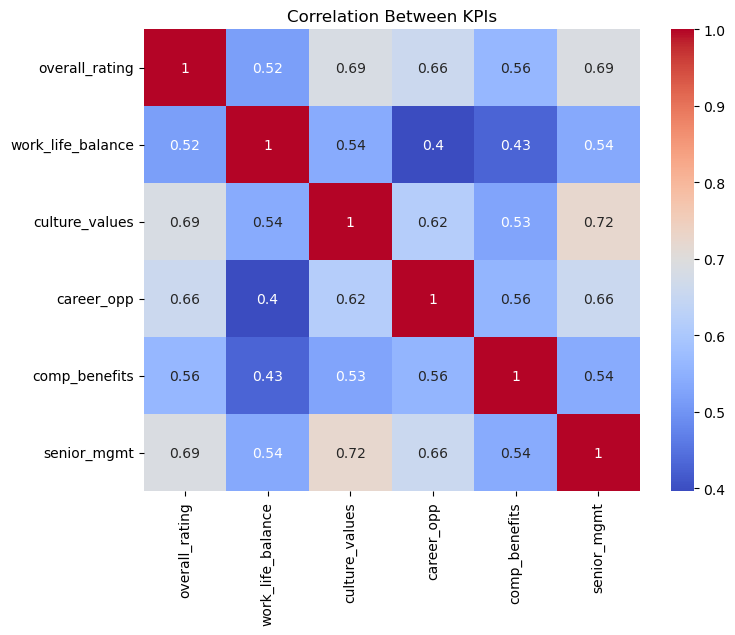

In [101]:
import seaborn as sns

cols = ['overall_rating','work_life_balance','culture_values',
        'career_opp','comp_benefits','senior_mgmt']

plt.figure(figsize=(8,6))
sns.heatmap(Review[cols].corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Between KPIs")
plt.show()

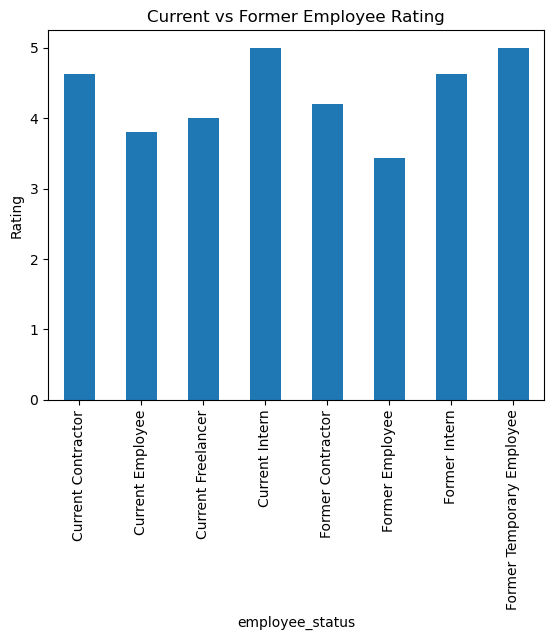

In [109]:
Review.groupby('employee_status')['overall_rating'].mean().plot(kind='bar')

plt.title                            ("Current vs Former Employee Rating")
plt.ylabel("Rating")
plt.show()

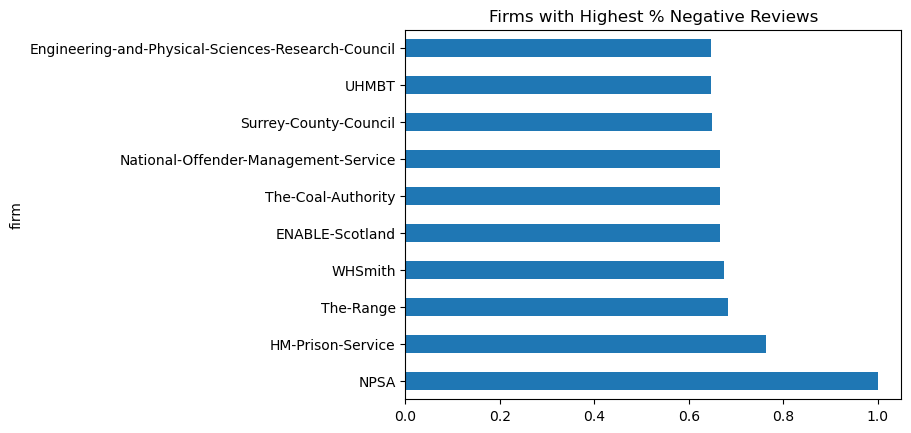

In [111]:
neg_pct = (
    Review.assign(is_negative = Review['cons_sentiment'] == 'Negative')
    .groupby('firm')['is_negative']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

neg_pct.plot(kind='barh')
plt.title("Firms with Highest % Negative Reviews")
plt.show()